# part1 a

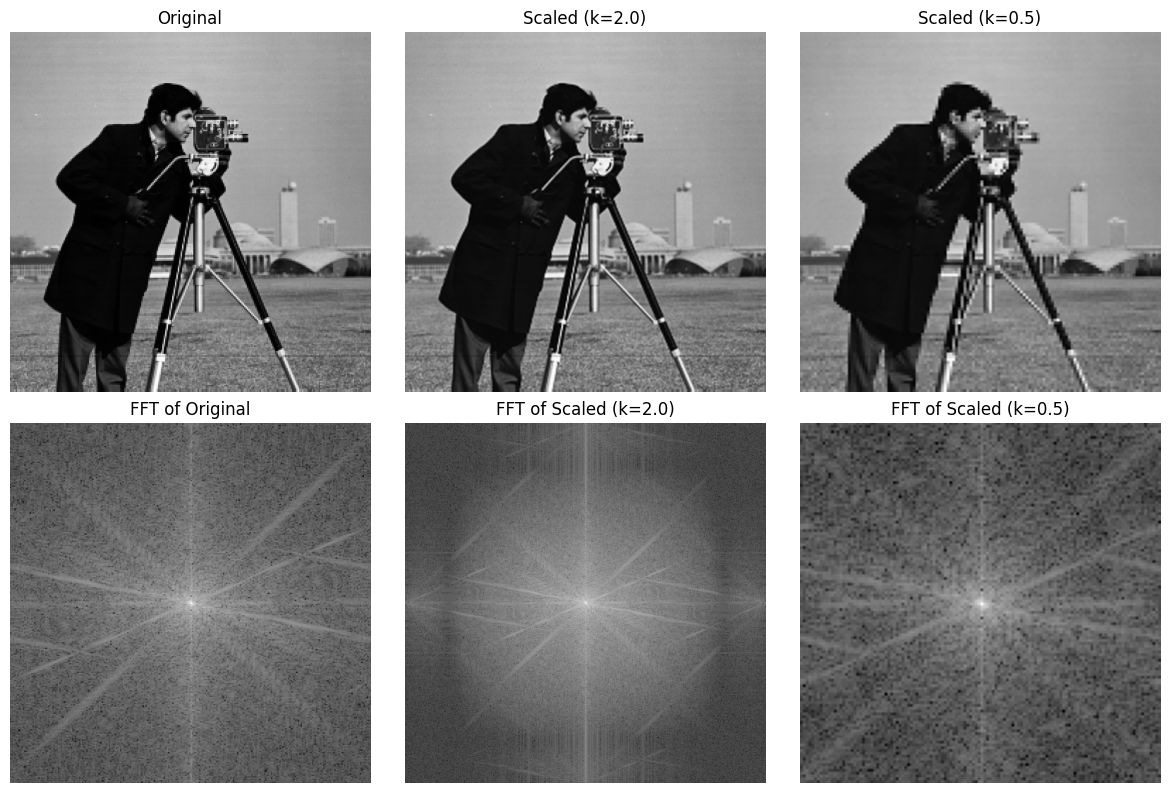

In [9]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load Cameraman image from current directory ---
# Make sure the image is in the same folder as this script, e.g. "cameraman.png"
img = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)

if img is None:
    raise FileNotFoundError("Cameraman image not found in the current directory!")

# --- Step 2: Define scaling factors ---
k_values = [2.0, 0.5]  # Zoom and shrink

# --- Step 3: Fourier transform helper ---
def fft_display(image):
    F = np.fft.fftshift(np.fft.fft2(image))
    magnitude = np.log1p(np.abs(F))
    magnitude /= magnitude.max()
    return magnitude

# --- Step 4: Scale images ---
images = {"Original": img}
for k in k_values:
    h, w = img.shape
    scaled = cv2.resize(img, (int(w*k), int(h*k)), interpolation=cv2.INTER_CUBIC)
    images[f"Scaled (k={k})"] = scaled

# --- Step 5: Display results ---
plt.figure(figsize=(12, 8))
n = len(images)

for i, (title, im) in enumerate(images.items()):
    # Spatial domain
    plt.subplot(2, n, i+1)
    plt.imshow(im, cmap='gray')
    plt.title(title)
    plt.axis('off')

    # Frequency domain
    plt.subplot(2, n, i+1+n)
    plt.imshow(fft_display(im), cmap='gray')
    plt.title(f"FFT of {title}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# part1 b

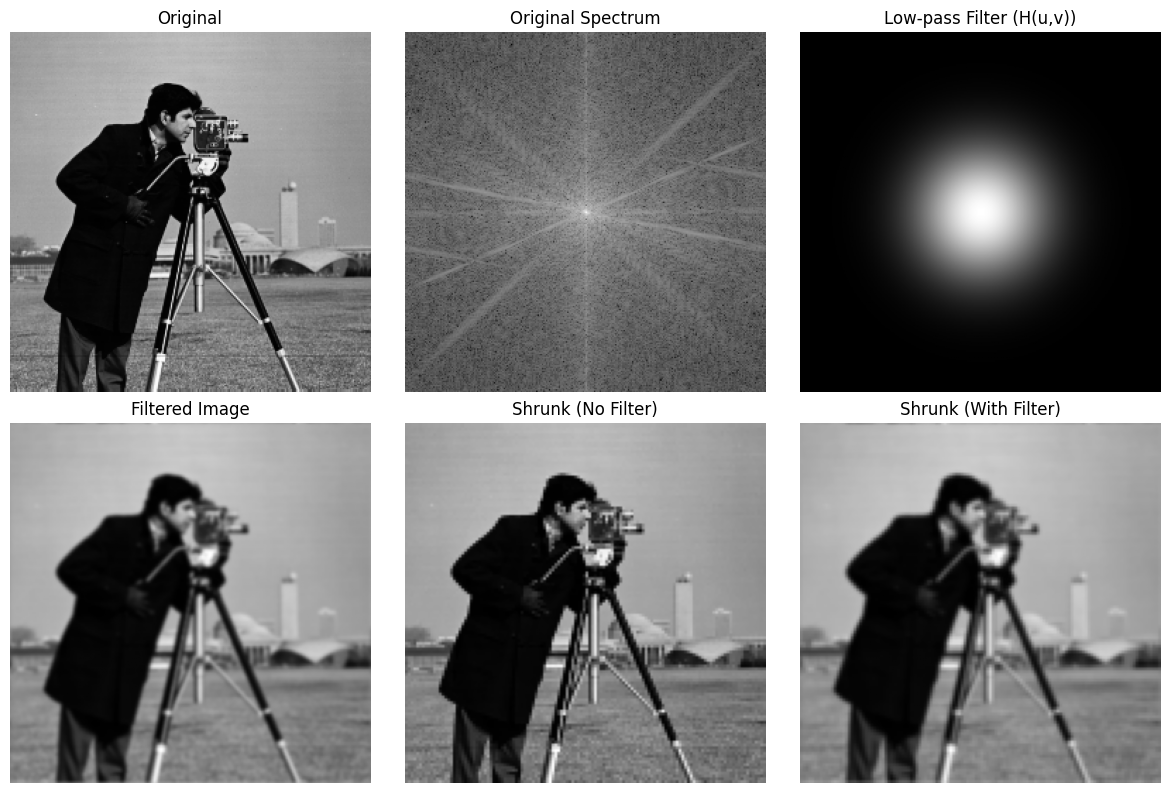

In [15]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load Cameraman image (from current directory) ---
img = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Could not find 'cameraman.png' in current directory.")

# --- Step 2: Define shrink factor ---
k = 0.5  # shrink by half

# --- Step 3: Create frequency-domain Gaussian low-pass filter ---
def lowpass_filter(shape, cutoff):
    M, N = shape
    u = np.arange(-M//2, M//2)
    v = np.arange(-N//2, N//2)
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = np.exp(-(D**2) / (2 * (cutoff**2)))
    return H

# Compute 2D FFT
F = np.fft.fftshift(np.fft.fft2(img))
M, N = img.shape
cutoff = min(M, N) * k * 0.25  # cutoff proportional to shrink factor
H = lowpass_filter((M, N), cutoff)

# Apply low-pass filter
F_filtered = F * H
img_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))

# --- Step 4: Downsample ---
h, w = img_filtered.shape
shrunk_naive = cv2.resize(img, (int(w*k), int(h*k)), interpolation=cv2.INTER_AREA)
shrunk_filtered = cv2.resize(img_filtered, (int(w*k), int(h*k)), interpolation=cv2.INTER_AREA)

# --- Step 5: Display results ---
plt.figure(figsize=(12, 8))

plt.subplot(2,3,1)
plt.imshow(img, cmap='gray')
plt.title("Original")
plt.axis('off')

plt.subplot(2,3,2)
plt.imshow(np.log1p(np.abs(F)), cmap='gray')
plt.title("Original Spectrum")
plt.axis('off')

plt.subplot(2,3,3)
plt.imshow(H, cmap='gray')
plt.title("Low-pass Filter (H(u,v))")
plt.axis('off')

plt.subplot(2,3,4)
plt.imshow(img_filtered, cmap='gray')
plt.title("Filtered Image")
plt.axis('off')

plt.subplot(2,3,5)
plt.imshow(shrunk_naive, cmap='gray')
plt.title("Shrunk (No Filter)")
plt.axis('off')

plt.subplot(2,3,6)
plt.imshow(shrunk_filtered, cmap='gray')
plt.title("Shrunk (With Filter)")
plt.axis('off')

plt.tight_layout()
plt.show()


# part 1 c

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Helper: Create ideal low-pass filter ----------
def lowpass_filter(shape, cutoff):
    M, N = shape
    u = np.arange(-M//2, M//2)
    v = np.arange(-N//2, N//2)
    U, V = np.meshgrid(u, v, indexing='ij')
    D = np.sqrt(U**2 + V**2)
    H = (D <= cutoff).astype(float)  # ideal circular LPF
    return H

# ---------- Helper: Frequency-domain filtering ----------
def freq_domain_resize(img, k):
    """Shrink image by factor k with frequency-domain low-pass filtering."""
    M, N = img.shape
    # FFT
    F = np.fft.fftshift(np.fft.fft2(img))
    cutoff = min(M, N) * k * 0.5  # cutoff proportional to shrink factor
    H = lowpass_filter((M, N), cutoff)
    # Apply LPF
    F_filt = F * H
    img_filt = np.real(np.fft.ifft2(np.fft.ifftshift(F_filt)))
    # Downsample
    new_size = (int(N * k), int(M * k))
    shrunk = cv2.resize(img_filt, new_size, interpolation=cv2.INTER_AREA)
    return shrunk, H

# ---------- Step 1: Load the Barbara image ----------
img = cv2.imread("test-images/barbara.bmp", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Could not find 'barbara.png' in the current directory!")

# ---------- Step 2: Shrink factors ----------
k_values = [0.5, 0.25, 0.125]

# ---------- Step 3: Perform both resizing methods ----------
results_naive = []
results_filtered = []

for k in k_values:
    # Naive interpolation only
    h, w = img.shape
    naive = cv2.resize(img, (int(w*k), int(h*k)), interpolation=cv2.INTER_AREA)
    # Frequency-domain filtered
    filtered, H = freq_domain_resize(img, k)
    results_naive.append(naive)
    results_filtered.append(filtered)

# ---------- Step 4: Visualize results ----------
plt.figure(figsize=(14, 10))
plt.suptitle("Barbara Image — Naive vs Frequency-Domain Filtering for Shrinking", fontsize=14)

for i, k in enumerate(k_values):
    # Naive shrink
    plt.subplot(3, len(k_values), i+1)
    plt.imshow(results_naive[i], cmap='gray')
    plt.title(f"Naive shrink k={k}")
    plt.axis('off')

    # Filtered shrink
    plt.subplot(3, len(k_values), i+1+len(k_values))
    plt.imshow(results_filtered[i], cmap='gray')
    plt.title(f"Filtered shrink k={k}")
    plt.axis('off')

    # Zoomed back to original size for visual comparison
    zoom_naive = cv2.resize(results_naive[i], (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)
    zoom_filt = cv2.resize(results_filtered[i], (img.shape[1], img.shape[0]), interpolation=cv2.INTER_NEAREST)

    diff = np.abs(zoom_naive - zoom_filt)

    plt.subplot(3, len(k_values), i+1+2*len(k_values))
    plt.imshow(np.hstack((zoom_naive, zoom_filt)), cmap='gray')
    plt.title(f"Zoomed back (Naive | Filtered)\n k={k}")
    plt.axis('off')

plt.tight_layout()
plt.show()


# part 2a

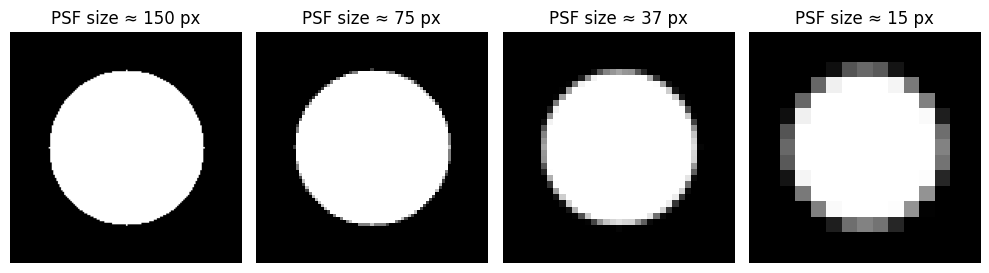

PSF 1: shape=(150, 150), sum=1.0000
PSF 2: shape=(75, 75), sum=1.0000
PSF 3: shape=(37, 37), sum=1.0000
PSF 4: shape=(15, 15), sum=1.0000


In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Create a bright circular PSF (aperture shape) ---
def make_disk_psf(size):
    """Generate a circular aperture (bright disk on black)."""
    h, w = size, size
    psf = np.zeros((h, w), dtype=np.float32)
    rr, cc = np.ogrid[:h, :w]
    center = (h // 2, w // 2)
    radius = size // 3  # disk radius
    mask = (rr - center[0])**2 + (cc - center[1])**2 <= radius**2
    psf[mask] = 1.0
    return psf

# --- Step 2: Resize function (from previous tasks or cv2.resize) ---
def resize_psf(psf, k):
    """Resize PSF by factor k and renormalize."""
    new_size = (max(1, int(psf.shape[1]*k)), max(1, int(psf.shape[0]*k)))
    resized = cv2.resize(psf, new_size, interpolation=cv2.INTER_AREA)
    # Normalize so sum = 1
    resized = resized / np.sum(resized)
    return resized

# --- Step 3: Generate PSFs of multiple sizes ---
base_psf = make_disk_psf(150)
scales = [1.0, 0.5, 0.25, 0.1]  # roughly 150px → 10–40px smallest
psf_list = [resize_psf(base_psf, k) for k in scales]

# --- Step 4: Display results ---
plt.figure(figsize=(10, 3))
for i, (k, psf) in enumerate(zip(scales, psf_list)):
    plt.subplot(1, len(scales), i+1)
    plt.imshow(psf, cmap='gray')
    plt.title(f"PSF size ≈ {psf.shape[0]} px")
    plt.axis('off')
plt.tight_layout()
plt.show()

# --- Optional: verify normalization ---
for i, psf in enumerate(psf_list):
    print(f"PSF {i+1}: shape={psf.shape}, sum={np.sum(psf):.4f}")


# part 2b

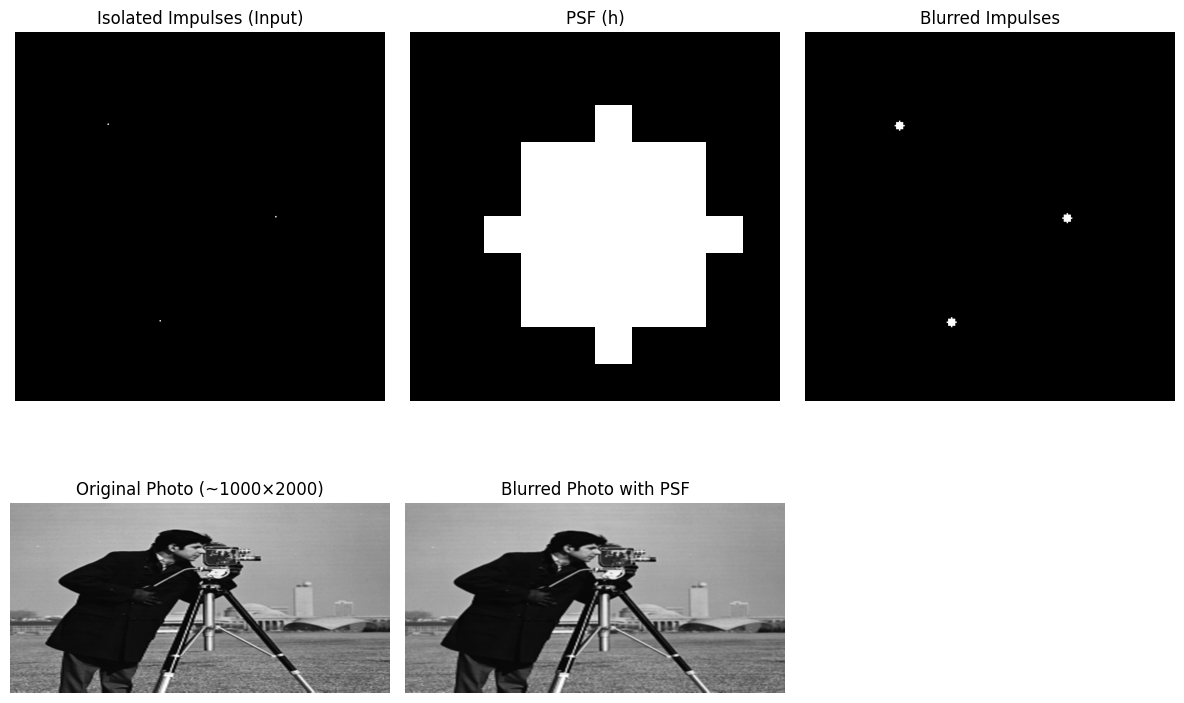

In [23]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve2d

# ---------- Step 1: Load or reuse smallest PSF from part 2(a) ----------
def make_disk_psf(size):
    """Generate a normalized circular PSF (bright disk)."""
    psf = np.zeros((size, size), np.float32)
    rr, cc = np.ogrid[:size, :size]
    c = size // 2
    mask = (rr - c)**2 + (cc - c)**2 <= (size // 3)**2
    psf[mask] = 1.0
    psf /= psf.sum()
    return psf

psf = make_disk_psf(10)   # smallest PSF

# ---------- Step 2: Mirror padding helper ----------
def mirror_pad(img, pad):
    return np.pad(img, pad, mode='reflect')

# ---------- Step 3a: Impulse image ----------
impulse_img = np.zeros((256, 256), np.float32)
impulse_img[64, 64] = 1
impulse_img[128, 180] = 1
impulse_img[200, 100] = 1

# Mirror-pad before convolution
pad = psf.shape[0] // 2
impulse_padded = mirror_pad(impulse_img, pad)

# Convolve with PSF (kernel centered)
blurred_impulse = convolve2d(impulse_padded, psf, mode='same', boundary='symm')

# Crop back to original size
blurred_impulse = blurred_impulse[pad:-pad, pad:-pad]

# ---------- Step 3b: Real photo (e.g., Cameraman or your own) ----------
img = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Place a photo like 'cameraman.png' in the current directory!")

# Resize to roughly 1000×2000 if needed
img_large = cv2.resize(img, (2000, 1000), interpolation=cv2.INTER_CUBIC)
img_large = img_large.astype(np.float32) / 255.0

# Mirror padding and convolution
pad = psf.shape[0] // 2
img_padded = mirror_pad(img_large, pad)
blurred_large = convolve2d(img_padded, psf, mode='same', boundary='symm')
blurred_large = blurred_large[pad:-pad, pad:-pad]

# ---------- Step 4: Display results ----------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(impulse_img, cmap='gray')
plt.title("Isolated Impulses (Input)")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(psf, cmap='gray')
plt.title("PSF (h)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(blurred_impulse, cmap='gray')
plt.title("Blurred Impulses")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(img_large, cmap='gray')
plt.title("Original Photo (~1000×2000)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(blurred_large, cmap='gray')
plt.title("Blurred Photo with PSF")
plt.axis('off')

plt.tight_layout()
plt.show()


# part 2c

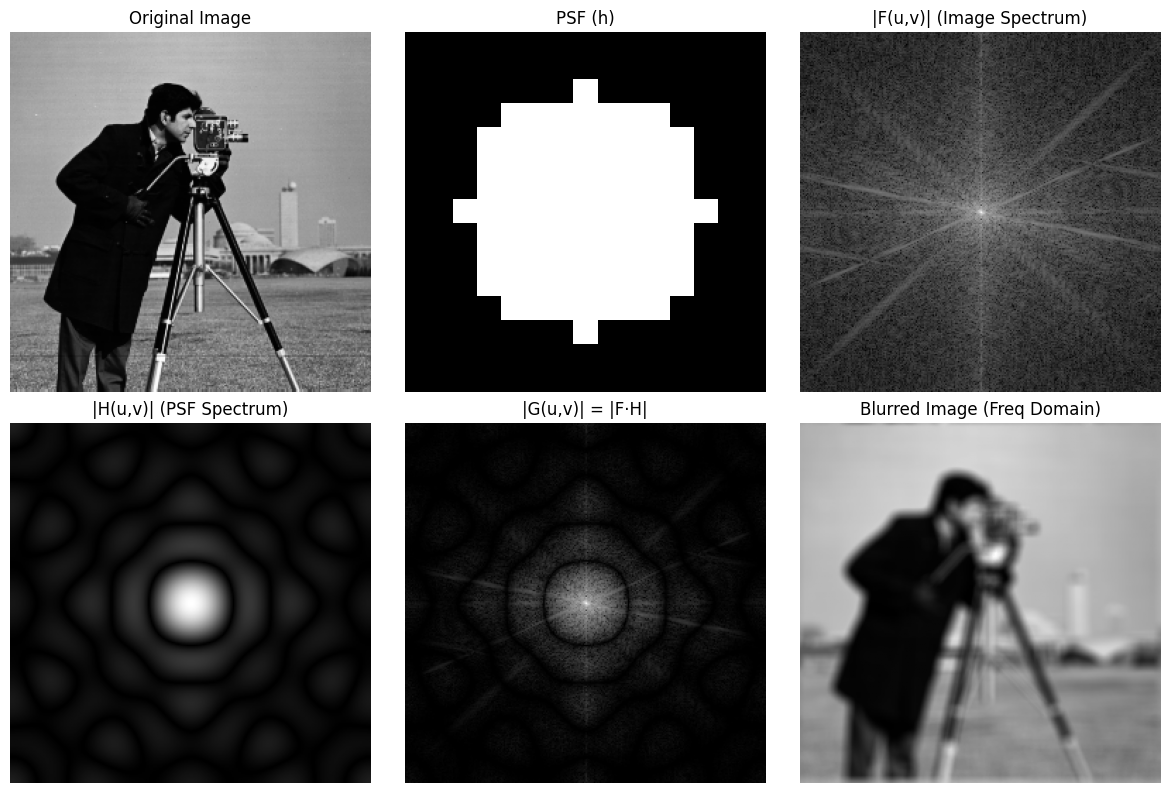

In [26]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# ---------- Step 1: Helper functions ----------

def make_disk_psf(size):
    """Generate a normalized circular PSF (bright disk)."""
    psf = np.zeros((size, size), np.float32)
    rr, cc = np.ogrid[:size, :size]
    c = size // 2
    mask = (rr - c)**2 + (cc - c)**2 <= (size // 3)**2
    psf[mask] = 1.0
    psf /= psf.sum()
    return psf

def fft_blur(img, psf):
    """Perform blurring in the frequency domain."""
    M, N = img.shape
    m, n = psf.shape

    # Pad PSF to image size and center
    pad_psf = np.zeros_like(img)
    pad_psf[:m, :n] = psf
    pad_psf = np.roll(pad_psf, -m//2, axis=0)
    pad_psf = np.roll(pad_psf, -n//2, axis=1)

    # FFT of both
    F = np.fft.fft2(img)
    H = np.fft.fft2(pad_psf)
    G = F * H

    # Inverse FFT
    g = np.real(np.fft.ifft2(G))
    return g, F, H, G

# ---------- Step 2: Load image ----------
img = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Place 'cameraman.png' in this directory.")

img = img.astype(np.float32) / 255.0
psf = make_disk_psf(15)  # small PSF from 2(a)

# ---------- Step 3: Apply frequency-domain blur ----------
blurred_fft, F, H, G = fft_blur(img, psf)

# ---------- Step 4: Display intermediate results ----------
plt.figure(figsize=(12, 8))

plt.subplot(2, 3, 1)
plt.imshow(img, cmap='gray')
plt.title("Original Image")
plt.axis('off')

plt.subplot(2, 3, 2)
plt.imshow(psf, cmap='gray')
plt.title("PSF (h)")
plt.axis('off')

plt.subplot(2, 3, 3)
plt.imshow(np.log1p(np.abs(np.fft.fftshift(F))), cmap='gray')
plt.title("|F(u,v)| (Image Spectrum)")
plt.axis('off')

plt.subplot(2, 3, 4)
plt.imshow(np.log1p(np.abs(np.fft.fftshift(H))), cmap='gray')
plt.title("|H(u,v)| (PSF Spectrum)")
plt.axis('off')

plt.subplot(2, 3, 5)
plt.imshow(np.log1p(np.abs(np.fft.fftshift(G))), cmap='gray')
plt.title("|G(u,v)| = |F·H|")
plt.axis('off')

plt.subplot(2, 3, 6)
plt.imshow(blurred_fft, cmap='gray')
plt.title("Blurred Image (Freq Domain)")
plt.axis('off')

plt.tight_layout()
plt.show()


# part 2d

Kernel 5×5 → spatial 0.0034s, freq 0.0054s
Kernel 11×11 → spatial 0.0121s, freq 0.0145s
Kernel 21×21 → spatial 0.0612s, freq 0.0199s
Kernel 41×41 → spatial 0.1067s, freq 0.0055s
Kernel 81×81 → spatial 0.4210s, freq 0.0079s
Kernel 161×161 → spatial 1.9121s, freq 0.0092s
Kernel 321×321 → spatial 8.3089s, freq 0.0168s


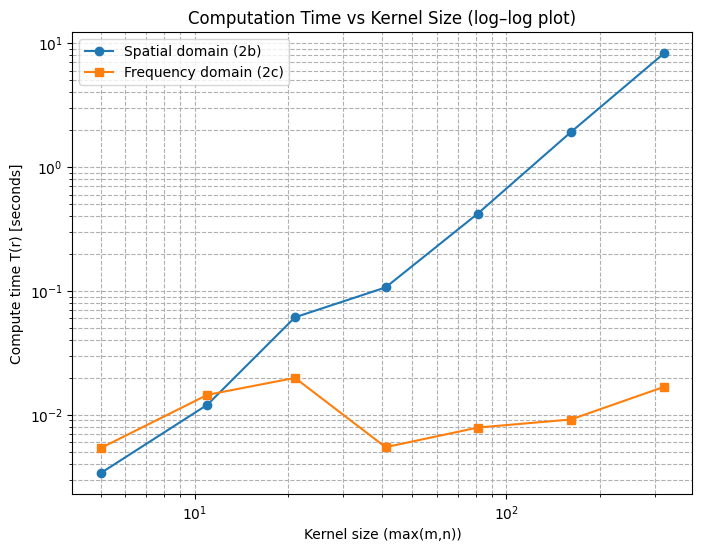

In [28]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import time
from scipy.signal import convolve2d

# ---------- Helpers ----------

def make_disk_psf(size):
    psf = np.zeros((size, size), np.float32)
    rr, cc = np.ogrid[:size, :size]
    c = size // 2
    mask = (rr - c)**2 + (cc - c)**2 <= (size // 3)**2
    psf[mask] = 1.0
    psf /= psf.sum()
    return psf

def spatial_convolve(img, psf):
    return convolve2d(img, psf, mode='same', boundary='symm')

def freq_convolve(img, psf):
    """Perform convolution via FFT with proper zero-padding."""
    M, N = img.shape
    m, n = psf.shape

    # Pad image and PSF to same large size (full convolution)
    P = M + m - 1
    Q = N + n - 1

    # Zero-pad both
    pad_img = np.zeros((P, Q), np.float32)
    pad_psf = np.zeros((P, Q), np.float32)
    pad_img[:M, :N] = img
    pad_psf[:m, :n] = psf

    # Center the PSF
    pad_psf = np.roll(pad_psf, -m//2, axis=0)
    pad_psf = np.roll(pad_psf, -n//2, axis=1)

    # Frequency domain multiplication
    F = np.fft.fft2(pad_img)
    H = np.fft.fft2(pad_psf)
    G = F * H

    # Inverse FFT and crop to original image size
    g = np.real(np.fft.ifft2(G))
    g = g[:M, :N]
    return g


# ---------- Load image ----------
img = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Place 'cameraman.png' in the current directory.")
img = img.astype(np.float32) / 255.0

# ---------- Kernel sizes to test ----------
kernel_sizes = [5, 11, 21, 41, 81, 161, 321]
times_spatial = []
times_freq = []

for k in kernel_sizes:
    psf = make_disk_psf(k)

    # Spatial convolution
    start = time.time()
    _ = spatial_convolve(img, psf)
    times_spatial.append(time.time() - start)

    # Frequency-domain convolution
    start = time.time()
    _ = freq_convolve(img, psf)
    times_freq.append(time.time() - start)

    print(f"Kernel {k}×{k} → spatial {times_spatial[-1]:.4f}s, freq {times_freq[-1]:.4f}s")

# ---------- Plot results ----------
plt.figure(figsize=(8,6))
plt.loglog(kernel_sizes, times_spatial, 'o-', label='Spatial domain (2b)')
plt.loglog(kernel_sizes, times_freq, 's-', label='Frequency domain (2c)')
plt.xlabel("Kernel size (max(m,n))")
plt.ylabel("Compute time T(r) [seconds]")
plt.title("Computation Time vs Kernel Size (log–log plot)")
plt.legend()
plt.grid(True, which="both", ls="--")
plt.show()


# part 3a

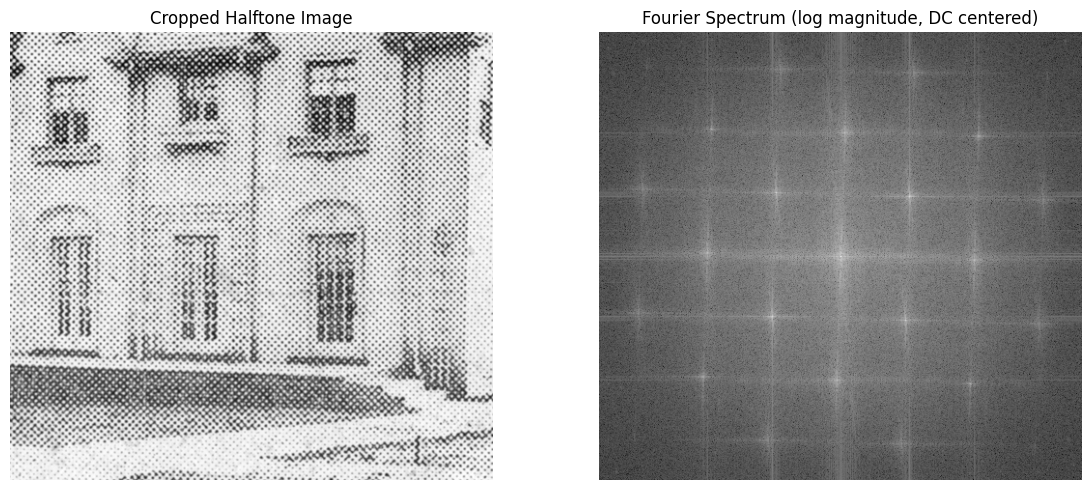

In [32]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load halftone image ---
img = cv2.imread("test-images/halftone_sample.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Please place a halftone image named 'halftone_sample.jpg' in the current directory!")

# --- Step 2: Optional crop for visible dot region ---
# Modify indices as needed
cropped = img[200:700, 200:700]

# --- Step 3: Compute FFT (without padding) ---
F = np.fft.fft2(cropped)
Fshift = np.fft.fftshift(F)   # center the DC component
magnitude = np.log1p(np.abs(Fshift))

# --- Step 4: Display results ---
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(cropped, cmap='gray')
plt.title("Cropped Halftone Image")
plt.axis('off')

plt.subplot(1,2,2)
plt.imshow(magnitude, cmap='gray')
plt.title("Fourier Spectrum (log magnitude, DC centered)")
plt.axis('off')

plt.tight_layout()
plt.show()


# part 3c

/var/folders/dd/vfnx3x1x2bvbyk9k4dgpt0jh0000gn/T/ipykernel_87118/3966250102.py:36: RuntimeWarning: divide by zero encountered in divide
  H *= 1 / (1 + (D0 / Dk)**(2*n))
/var/folders/dd/vfnx3x1x2bvbyk9k4dgpt0jh0000gn/T/ipykernel_87118/3966250102.py:37: RuntimeWarning: divide by zero encountered in divide
  H *= 1 / (1 + (D0 / Dk_sym)**(2*n))


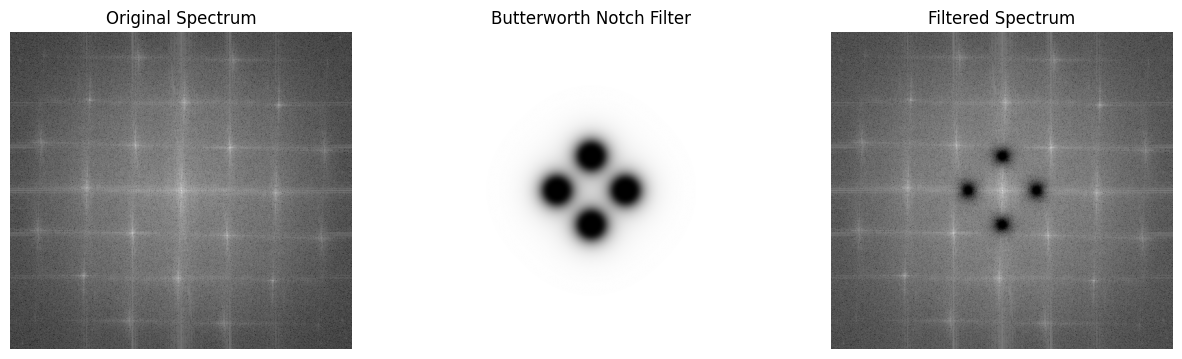

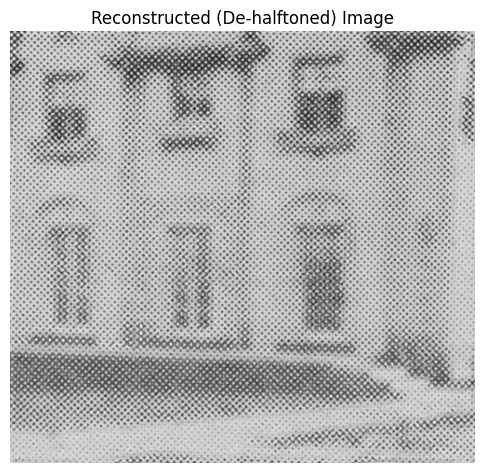

In [35]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load & crop halftone image ---
img = cv2.imread("test-images/halftone_sample.jpg", cv2.IMREAD_GRAYSCALE)
if img is None:
    raise FileNotFoundError("Please add your halftone image file.")

cropped = img[200:700, 200:700]

# --- Step 2: FFT & shift ---
F = np.fft.fft2(cropped)
Fshift = np.fft.fftshift(F)
magnitude = np.log1p(np.abs(Fshift))

# --- Step 3: Define Butterworth Notch Filter parameters ---
rows, cols = cropped.shape
crow, ccol = rows//2, cols//2

# approximate spike offsets (edit as needed after inspecting spectrum)
# for example, if spikes are around ±50 px horizontally & vertically:
notch_centers = [(crow, ccol+50), (crow, ccol-50),
                 (crow+50, ccol), (crow-50, ccol)]

D0 = 20  # cutoff radius
n = 2    # Butterworth order

# --- Step 4: Construct the filter ---
U, V = np.meshgrid(np.arange(cols), np.arange(rows))
H = np.ones((rows, cols), np.float32)

for (r0, c0) in notch_centers:
    Dk = np.sqrt((U - c0)**2 + (V - r0)**2)
    Dk_sym = np.sqrt((U - (2*ccol - c0))**2 + (V - (2*crow - r0))**2)
    H *= 1 / (1 + (D0 / Dk)**(2*n))
    H *= 1 / (1 + (D0 / Dk_sym)**(2*n))

# --- Step 5: Apply filter & inverse FFT ---
F_filtered = Fshift * H
filtered_spectrum = np.log1p(np.abs(F_filtered))
img_filtered = np.real(np.fft.ifft2(np.fft.ifftshift(F_filtered)))

# --- Step 6: Display results ---
plt.figure(figsize=(15,6))
plt.subplot(1,3,1)
plt.imshow(magnitude, cmap='gray')
plt.title("Original Spectrum")
plt.axis('off')

plt.subplot(1,3,2)
plt.imshow(H, cmap='gray')
plt.title("Butterworth Notch Filter")
plt.axis('off')

plt.subplot(1,3,3)
plt.imshow(filtered_spectrum, cmap='gray')
plt.title("Filtered Spectrum")
plt.axis('off')
plt.show()

plt.figure(figsize=(6,6))
plt.imshow(img_filtered, cmap='gray')
plt.title("Reconstructed (De-halftoned) Image")
plt.axis('off')
plt.show()


# part 4 a

Saved generated_noisy_images/c1_uniform.png | PSNR = 20.02 dB
Saved generated_noisy_images/c2_gaussian.png | PSNR = 20.01 dB
Saved generated_noisy_images/c3_sp.png | PSNR = 16.05 dB
Saved generated_noisy_images/f1_uniform.png | PSNR = 20.38 dB
Saved generated_noisy_images/f2_gaussian.png | PSNR = 20.42 dB
Saved generated_noisy_images/f3_sp.png | PSNR = 15.11 dB


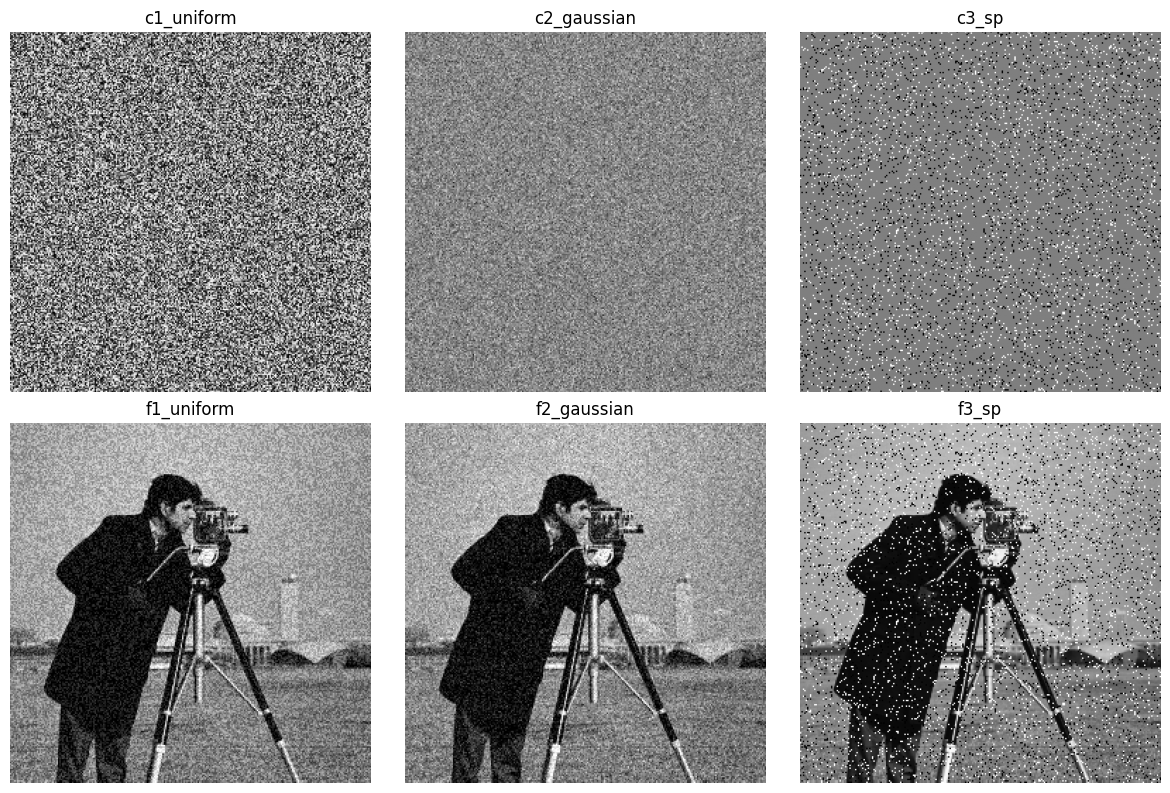

In [40]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# --- Step 1: Create constant image c ---
rows, cols = 256, 256
Imax = 255
c = np.ones((rows, cols), dtype=np.float32) * (Imax / 2)

# --- Step 2: Load a natural image f ---
f = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if f is None:
    raise FileNotFoundError("Please include a grayscale natural image named 'cameraman.png' in the 'test-images' folder.")
f = cv2.resize(f, (rows, cols)).astype(np.float32)

# --- Helper function to compute PSNR ---
def psnr(original, noisy):
    mse = np.mean((original - noisy) ** 2)
    if mse == 0:
        return 100
    return 10 * np.log10((255 ** 2) / mse)

# --- Step 3: Define MSE target for PSNR = 20 dB ---
target_mse = 255**2 / (10**(20/10))
noise_std = np.sqrt(target_mse)

# --- Step 4: Add different noise types ---
# 1️⃣ Uniform noise
u_low, u_high = -np.sqrt(3) * noise_std, np.sqrt(3) * noise_std
c1 = c + np.random.uniform(u_low, u_high, c.shape)
f1 = f + np.random.uniform(u_low, u_high, f.shape)

# 2️⃣ Gaussian noise
c2 = c + np.random.normal(0, noise_std, c.shape)
f2 = f + np.random.normal(0, noise_std, f.shape)

# 3️⃣ Salt-and-pepper noise
p = 0.05  # adjust if PSNR not close to 20 dB
c3 = c.copy()
f3 = f.copy()
mask = np.random.choice([0, 0.5, 1], size=c.shape, p=[1-2*p, p, p])
c3[mask == 0.5] = 0
c3[mask == 1] = 255
f3[mask == 0.5] = 0
f3[mask == 1] = 255

# --- Step 5: Clip to [0,255] ---
def clip_uint8(x): 
    return np.clip(x, 0, 255).astype(np.uint8)

images = {
    "c1_uniform.png": clip_uint8(c1),
    "c2_gaussian.png": clip_uint8(c2),
    "c3_sp.png": clip_uint8(c3),
    "f1_uniform.png": clip_uint8(f1),
    "f2_gaussian.png": clip_uint8(f2),
    "f3_sp.png": clip_uint8(f3)
}

# --- Step 6: Save all images ---
save_dir = "generated_noisy_images"
os.makedirs(save_dir, exist_ok=True)

for filename, img in images.items():
    path = os.path.join(save_dir, filename)
    cv2.imwrite(path, img)
    base = c if filename.startswith('c') else f
    print(f"Saved {path} | PSNR = {psnr(base, img):.2f} dB")

# --- Step 7: Display results ---
plt.figure(figsize=(12,8))
for i, (name, img) in enumerate(images.items()):
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(name.replace('.png',''))
    plt.axis('off')
plt.tight_layout()
plt.show()


# part 4b

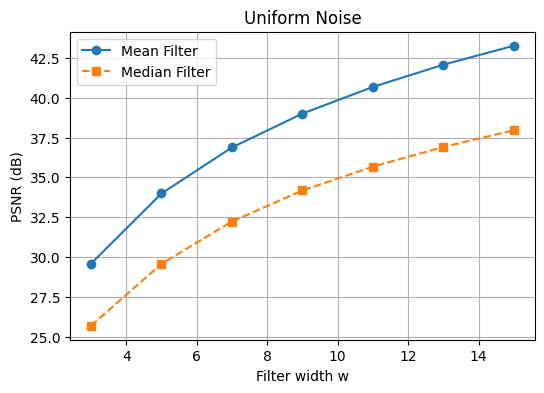

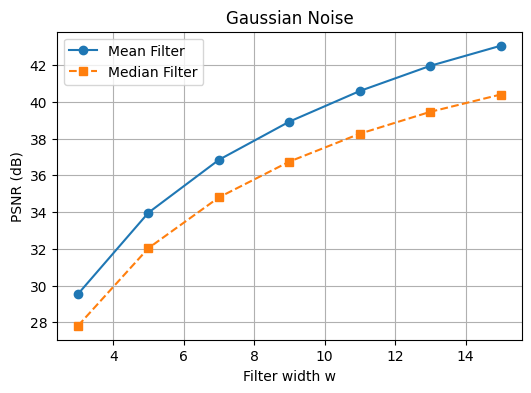

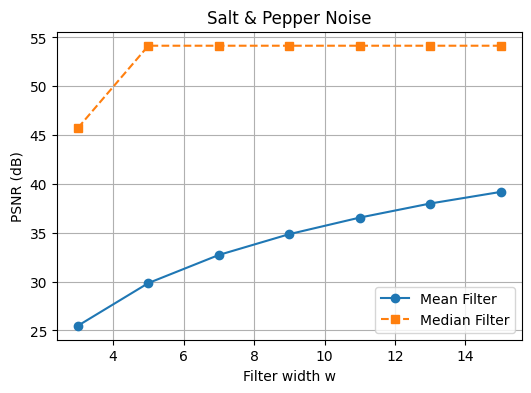

In [41]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Setup ---
rows, cols = 256, 256
Imax = 255
c = np.ones((rows, cols), dtype=np.float32) * (Imax / 2)

# Assume noisy versions already created from Q4(a)
# (You can paste your previous c1, c2, c3 generation code here)
# Example placeholders:
c1 = cv2.imread("generated_noisy_images/c1_uniform.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
c2 = cv2.imread("generated_noisy_images/c2_gaussian.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
c3 = cv2.imread("generated_noisy_images/c3_sp.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)

# --- Step 2: Helper for PSNR ---
def psnr(orig, denoised):
    mse = np.mean((orig - denoised) ** 2)
    if mse == 0: return 100
    return 10 * np.log10((255 ** 2) / mse)

# --- Step 3: Filtering and evaluation ---
widths = [3, 5, 7, 9, 11, 13, 15]
noisy_images = [("Uniform", c1), ("Gaussian", c2), ("Salt & Pepper", c3)]

for name, noisy in noisy_images:
    psnr_mean, psnr_median = [], []

    for w in widths:
        mean_filtered = cv2.blur(noisy, (w, w))
        median_filtered = cv2.medianBlur(noisy.astype(np.uint8), w)

        psnr_mean.append(psnr(c, mean_filtered))
        psnr_median.append(psnr(c, median_filtered))

    # --- Step 4: Plot results ---
    plt.figure(figsize=(6,4))
    plt.plot(widths, psnr_mean, 'o-', label='Mean Filter')
    plt.plot(widths, psnr_median, 's--', label='Median Filter')
    plt.xlabel("Filter width w")
    plt.ylabel("PSNR (dB)")
    plt.title(f"{name} Noise")
    plt.legend()
    plt.grid(True)
    plt.show()


# part 4c

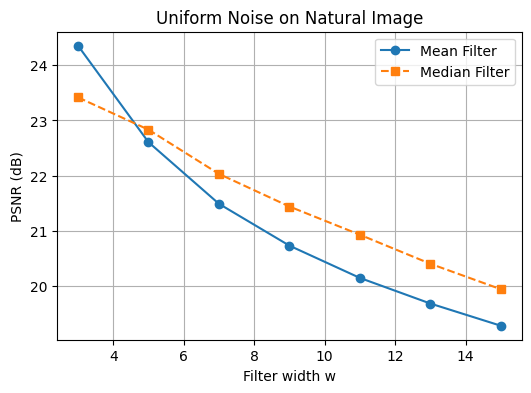

Uniform Noise → Best Mean Filter w=3, PSNR=24.35
Uniform Noise → Best Median Filter w=3, PSNR=23.42


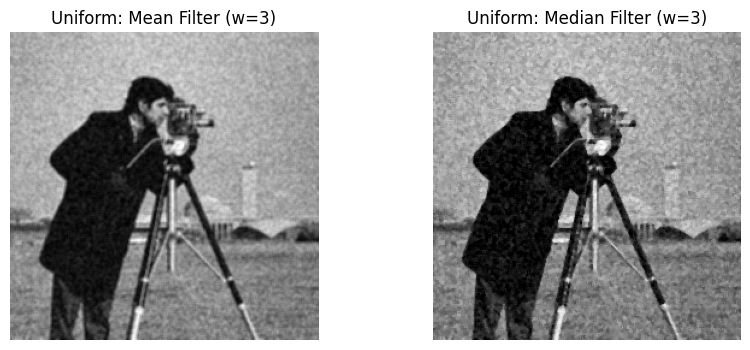

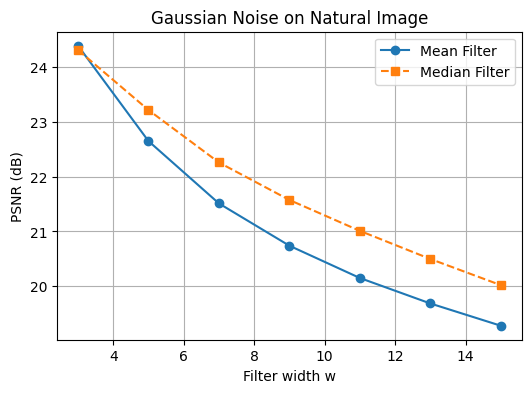

Gaussian Noise → Best Mean Filter w=3, PSNR=24.39
Gaussian Noise → Best Median Filter w=3, PSNR=24.31


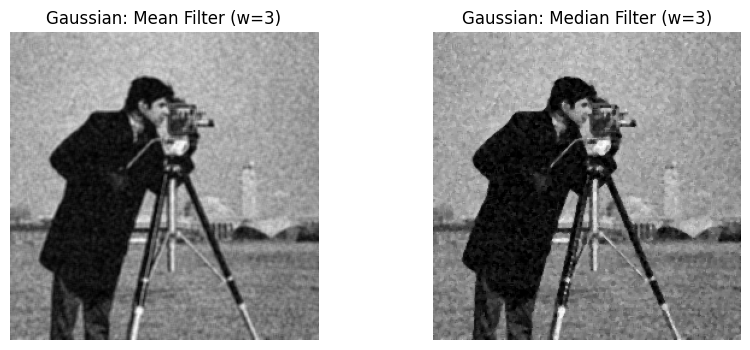

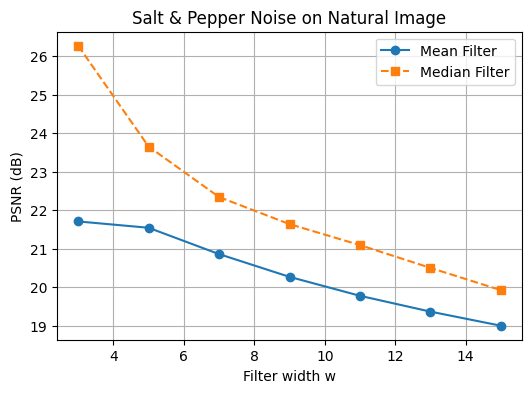

Salt & Pepper Noise → Best Mean Filter w=3, PSNR=21.71
Salt & Pepper Noise → Best Median Filter w=3, PSNR=26.27


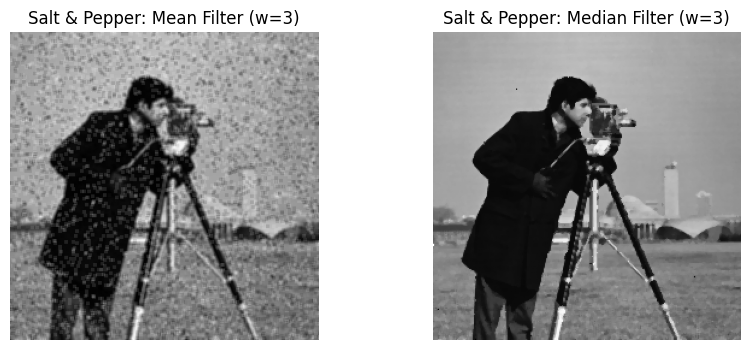

In [43]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load clean and noisy natural images ---
f = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
f = cv2.resize(f, (256, 256))

# noisy images from Q4(a)
f1 = cv2.imread("generated_noisy_images/f1_uniform.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
f2 = cv2.imread("generated_noisy_images/f2_gaussian.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)
f3 = cv2.imread("generated_noisy_images/f3_sp.png", cv2.IMREAD_GRAYSCALE).astype(np.float32)

# --- Step 2: PSNR function ---
def psnr(orig, denoised):
    mse = np.mean((orig - denoised) ** 2)
    if mse == 0: return 100
    return 10 * np.log10((255 ** 2) / mse)

# --- Step 3: Filter widths and loop ---
widths = [3, 5, 7, 9, 11, 13, 15]
noisy_images = [("Uniform", f1), ("Gaussian", f2), ("Salt & Pepper", f3)]

for name, noisy in noisy_images:
    psnr_mean, psnr_median = [], []

    for w in widths:
        mean_filtered = cv2.blur(noisy, (w, w))
        median_filtered = cv2.medianBlur(noisy.astype(np.uint8), w)
        psnr_mean.append(psnr(f, mean_filtered))
        psnr_median.append(psnr(f, median_filtered))

    # --- Step 4: Plot PSNR vs width ---
    plt.figure(figsize=(6,4))
    plt.plot(widths, psnr_mean, 'o-', label='Mean Filter')
    plt.plot(widths, psnr_median, 's--', label='Median Filter')
    plt.xlabel("Filter width w")
    plt.ylabel("PSNR (dB)")
    plt.title(f"{name} Noise on Natural Image")
    plt.legend()
    plt.grid(True)
    plt.show()

    # --- Step 5: Show best PSNR results ---
    best_w_mean = widths[np.argmax(psnr_mean)]
    best_w_median = widths[np.argmax(psnr_median)]

    best_mean = cv2.blur(noisy, (best_w_mean, best_w_mean))
    best_median = cv2.medianBlur(noisy.astype(np.uint8), best_w_median)

    print(f"{name} Noise → Best Mean Filter w={best_w_mean}, PSNR={max(psnr_mean):.2f}")
    print(f"{name} Noise → Best Median Filter w={best_w_median}, PSNR={max(psnr_median):.2f}")

    plt.figure(figsize=(10,4))
    plt.subplot(1,2,1)
    plt.imshow(best_mean, cmap='gray')
    plt.title(f"{name}: Mean Filter (w={best_w_mean})")
    plt.axis('off')
    plt.subplot(1,2,2)
    plt.imshow(best_median, cmap='gray')
    plt.title(f"{name}: Median Filter (w={best_w_median})")
    plt.axis('off')
    plt.show()


# part 5a

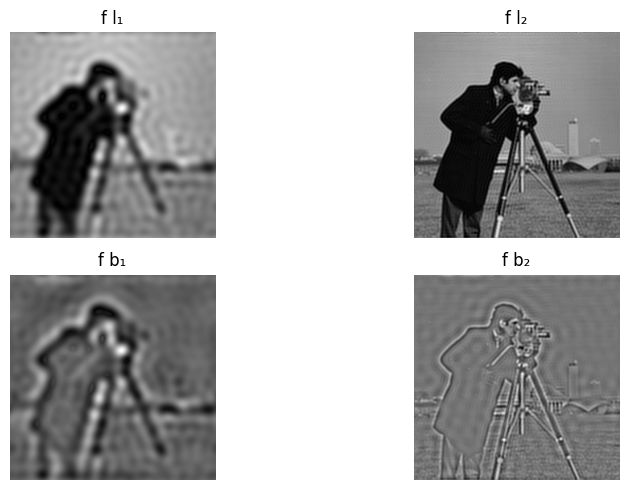

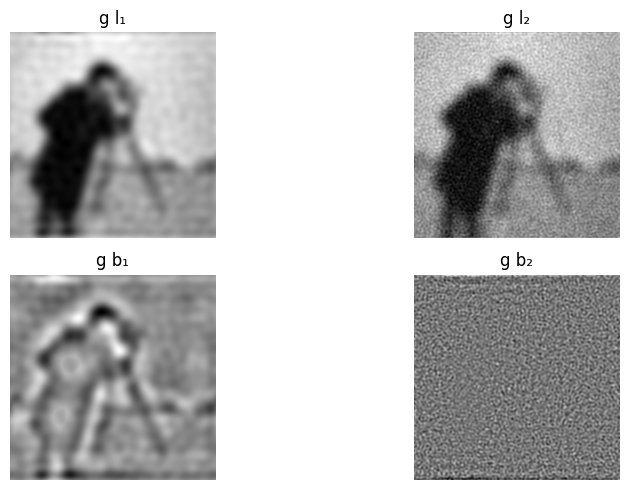

In [45]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load original and create degraded image ---
f = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if f is None:
    raise FileNotFoundError("Please include 'cameraman.png' in test-images/ directory.")
f = cv2.resize(f, (256, 256)).astype(np.float32)

# Blur + Gaussian noise (PSNR ≈ 20 dB)
f_blur = cv2.GaussianBlur(f, (21, 21), 10)
target_psnr = 20
mse = (255 ** 2) / (10 ** (target_psnr / 10))
noise_std = np.sqrt(mse)
g = f_blur + np.random.normal(0, noise_std, f.shape)
g = np.clip(g, 0, 255).astype(np.float32)

# --- Step 2: Compute FFTs ---
F = np.fft.fftshift(np.fft.fft2(f))
G = np.fft.fftshift(np.fft.fft2(g))
rows, cols = f.shape

# --- Step 3: Low-pass mask generator ---
def make_lowpass(shape, cutoff):
    Y, X = np.ogrid[:shape[0], :shape[1]]
    cy, cx = np.array(shape) // 2
    dist = np.sqrt((X - cx) ** 2 + (Y - cy) ** 2)
    mask = np.zeros(shape, np.float32)
    mask[dist <= cutoff] = 1
    return mask

# --- Step 4: Get low-pass and band-pass filtered images ---
def lowpass_bandpass(F, cutoffs):
    lowpasses = []
    for R in cutoffs:
        H = make_lowpass(F.shape, R)
        Ff = F * H
        f_recon = np.fft.ifft2(np.fft.ifftshift(Ff))
        lowpasses.append(np.abs(f_recon))
    bandpasses = [lowpasses[i] - lowpasses[i-1] for i in range(1, len(lowpasses))]
    return lowpasses, bandpasses

cutoffs = [4, 16, 64, 128]  # frequency radii
Lf, Bf = lowpass_bandpass(F, cutoffs)
Lg, Bg = lowpass_bandpass(G, cutoffs)

# --- Step 5: Visualization (show l1,l2,b1,b2 for f and g) ---
def normalize(img):
    img = img - np.min(img)
    img = img / np.max(img) * 255
    return img.astype(np.uint8)

def show_results(L, B, name):
    plt.figure(figsize=(10,5))
    plt.subplot(2,2,1); plt.imshow(normalize(L[1]), cmap='gray'); plt.title(f"{name} l₁"); plt.axis('off')
    plt.subplot(2,2,2); plt.imshow(normalize(L[2]), cmap='gray'); plt.title(f"{name} l₂"); plt.axis('off')
    plt.subplot(2,2,3); plt.imshow(normalize(B[0] + 128), cmap='gray'); plt.title(f"{name} b₁"); plt.axis('off')
    plt.subplot(2,2,4); plt.imshow(normalize(B[1] + 128), cmap='gray'); plt.title(f"{name} b₂"); plt.axis('off')
    plt.tight_layout()
    plt.show()

# --- Step 6: Display ---
show_results(Lf, Bf, "f")
show_results(Lg, Bg, "g")


# part 5b

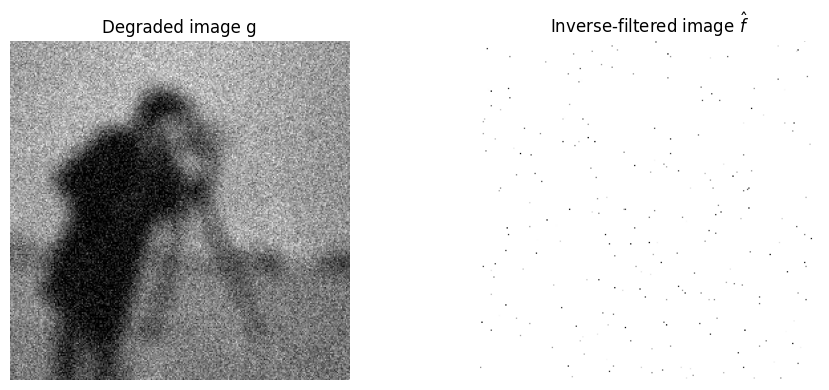

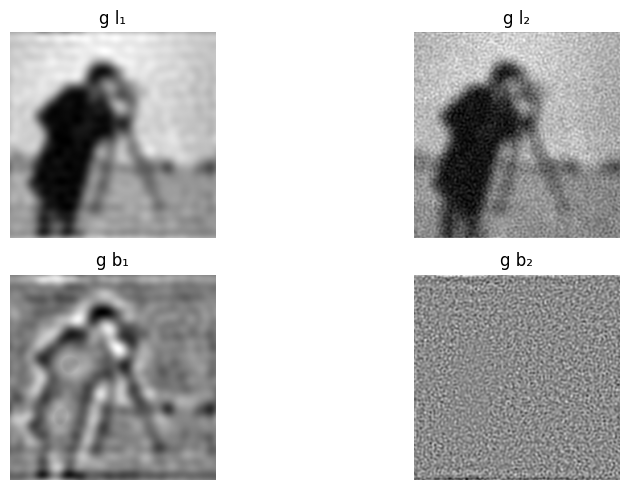

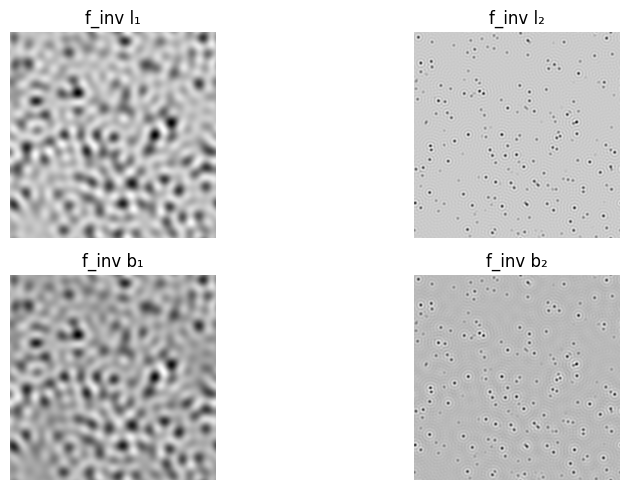

In [56]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# --- Step 1: Load original image and create degraded version g ---
f = cv2.imread("test-images/cameraman.png", cv2.IMREAD_GRAYSCALE)
if f is None:
    raise FileNotFoundError("Please include 'cameraman.png' in the 'test-images' folder.")
f = cv2.resize(f, (256, 256)).astype(np.float32)

# Add blur and Gaussian noise (PSNR ≈ 20 dB)
f_blur = cv2.GaussianBlur(f, (21, 21), 10)
target_psnr = 20
mse = (255**2) / (10**(target_psnr / 10))
noise_std = np.sqrt(mse)
g = f_blur + np.random.normal(0, noise_std, f.shape)
g = np.clip(g, 0, 255).astype(np.float32)

# --- Step 2: Create PSF (Gaussian blur kernel) and its FFT ---
def make_psf(shape, size=21, sigma=10):
    psf = cv2.getGaussianKernel(size, sigma)
    psf = psf @ psf.T
    psf /= psf.sum()
    h = np.zeros(shape, np.float32)
    h[:size, :size] = psf
    h = np.roll(h, -size // 2, axis=0)
    h = np.roll(h, -size // 2, axis=1)
    return h

h = make_psf(f.shape)
H = np.fft.fftshift(np.fft.fft2(h))
G = np.fft.fftshift(np.fft.fft2(g))

# --- Step 3: Inverse filtering ---
eps = 1e-3  # avoid division by zero
F_hat = G / (H + eps)
f_inv = np.abs(np.fft.ifft2(np.fft.ifftshift(F_hat)))
f_inv = np.clip(f_inv, 0, 255)

# --- Step 4: Display degraded and inverse-filtered images ---
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(g, cmap='gray')
plt.title("Degraded image g")
plt.axis('off')
plt.subplot(1, 2, 2)
plt.imshow(f_inv, cmap='gray')
plt.title(r"Inverse-filtered image $\hat{f}$")
plt.axis('off')
plt.tight_layout()
plt.show()

# --- Step 5: Visualize frequency bands ---
cutoffs = [4, 16, 64, 128]

def make_lowpass(shape, cutoff):
    Y, X = np.ogrid[:shape[0], :shape[1]]
    cy, cx = np.array(shape) // 2
    dist = np.sqrt((X - cx)**2 + (Y - cy)**2)
    mask = np.zeros(shape, np.float32)
    mask[dist <= cutoff] = 1
    return mask

def lowpass_bandpass(F):
    lowpasses = []
    for R in cutoffs:
        H = make_lowpass(F.shape, R)
        Ff = F * H
        lowpasses.append(np.abs(np.fft.ifft2(np.fft.ifftshift(Ff))))
    bandpasses = [lowpasses[i] - lowpasses[i - 1] for i in range(1, len(lowpasses))]
    return lowpasses, bandpasses

# Compute for degraded (g) and restored (f_inv)
Lf_inv, Bf_inv = lowpass_bandpass(np.fft.fftshift(np.fft.fft2(f_inv)))
Lg, Bg = lowpass_bandpass(G)

# --- Step 6: Display frequency bands ---
def normalize(img):
    img = img - np.min(img)
    img = img / np.max(img) * 255
    return img.astype(np.uint8)

def show_results(L, B, prefix):
    plt.figure(figsize=(10, 5))
    plt.subplot(2, 2, 1); plt.imshow(normalize(L[1]), cmap='gray'); plt.title(f"{prefix} l₁"); plt.axis('off')
    plt.subplot(2, 2, 2); plt.imshow(normalize(L[2]), cmap='gray'); plt.title(f"{prefix} l₂"); plt.axis('off')
    plt.subplot(2, 2, 3); plt.imshow(normalize(B[0] + 128), cmap='gray'); plt.title(f"{prefix} b₁"); plt.axis('off')
    plt.subplot(2, 2, 4); plt.imshow(normalize(B[1] + 128), cmap='gray'); plt.title(f"{prefix} b₂"); plt.axis('off')
    plt.tight_layout()
    plt.show()

show_results(Lg, Bg, "g")
show_results(Lf_inv, Bf_inv, "f_inv")


# part 5c

# part 5d

# part 5e